In [1]:
# ================================
# 1. IMPORT LIBRARIES
# ================================
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ================================
# 2. LOAD DATA
# ================================
df = pd.read_csv(r"D:\SLIIT UNI\Y4S2\ML\assignment 01\dataset\heart_disease_uci.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
# ================================
# 3. DATA PREPROCESSING
# ================================

df = df.dropna()

# Identify target column
target_column = 'target' if 'target' in df.columns else 'num'

X = df.drop(columns=[target_column])
y = df[target_column]

# Convert categorical → numeric
X = pd.get_dummies(X, drop_first=True)

# Save column structure
training_columns = X.columns.tolist()

# Convert target to binary
y = y.apply(lambda x: 1 if x > 0 else 0)

print("Processed Data Shape:", X.shape)

Processed Data Shape: (299, 21)


In [4]:
# ================================
# 4. SPLIT DATA
# ================================
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (179, 21)
Validation size: (60, 21)
Test size: (60, 21)


In [5]:
# ================================
# 5. FEATURE SCALING
# ================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [6]:
# ================================
# 6. TRAIN MODEL (KNN)
# ================================
model = KNeighborsClassifier(n_neighbors=5)

model.fit(X_train_scaled, y_train)

print("Model trained successfully")

Model trained successfully


In [7]:
# ================================
# 7. EVALUATION
# ================================
train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
val_acc = accuracy_score(y_val, model.predict(X_val_scaled))

test_pred = model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, test_pred)

precision = precision_score(y_test, test_pred)
recall = recall_score(y_test, test_pred)
f1 = f1_score(y_test, test_pred)

print("\n===== KNN RESULTS =====")
print(f"Training Accuracy   : {train_acc:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")
print(f"Test Accuracy       : {test_acc:.4f}")
print(f"Precision           : {precision:.4f}")
print(f"Recall              : {recall:.4f}")
print(f"F1 Score            : {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, test_pred))


===== KNN RESULTS =====
Training Accuracy   : 0.8436
Validation Accuracy : 0.7833
Test Accuracy       : 0.8500
Precision           : 0.9130
Recall              : 0.7500
F1 Score            : 0.8235

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.94      0.87        32
           1       0.91      0.75      0.82        28

    accuracy                           0.85        60
   macro avg       0.86      0.84      0.85        60
weighted avg       0.86      0.85      0.85        60



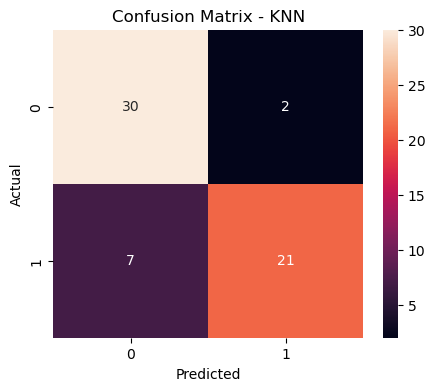

In [8]:
# ================================
# 8. CONFUSION MATRIX
# ================================
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [9]:
# ================================
# 9. SAVE MODEL
# ================================
import os

# Define save directory
save_path = r"D:\SLIIT UNI\Y4S2\ML\assignment 01\dataset\save_model"

# Create folder if it doesn't exist
os.makedirs(save_path, exist_ok=True)

# Save files
joblib.dump(model, os.path.join(save_path, "knn_model.pkl"))
joblib.dump(scaler, os.path.join(save_path, "scaler_knn.pkl"))
joblib.dump(training_columns, os.path.join(save_path, "columns_knn.pkl"))

print("KNN model saved successfully in:", save_path)

KNN model saved successfully in: D:\SLIIT UNI\Y4S2\ML\assignment 01\dataset\save_model


In [10]:
# ================================
# 10. MANUAL INPUT TESTING
# ================================

manual_input = {
    'age': 55,
    'sex': 'Male',
    'cp': 'asymptomatic',
    'trestbps': 140,
    'chol': 240,
    'fbs': True,
    'restecg': 'normal',
    'thalch': 150,
    'exang': False,
    'oldpeak': 1.5,
    'slope': 'flat',
    'ca': 0.0,
    'thal': 'fixed_defect'
}

input_df = pd.DataFrame([manual_input])

input_df = pd.get_dummies(input_df, drop_first=True)

for col in training_columns:
    if col not in input_df.columns:
        input_df[col] = 0

input_df = input_df[training_columns]

input_scaled = scaler.transform(input_df)

prediction = model.predict(input_scaled)[0]
probability = model.predict_proba(input_scaled)[0][1]

print("\n===== MANUAL TEST RESULT =====")
print("Prediction:", "Heart Disease" if prediction == 1 else "No Heart Disease")
print(f"Probability: {probability:.4f}")


===== MANUAL TEST RESULT =====
Prediction: No Heart Disease
Probability: 0.4000
